# HEL1OS (High Energy L1 Orbiting X-ray Spectrometer) Data Exploration

This notebook inspects the structure, schema, timestamps, sampling cadence, and light curve characteristics of Aditya-L1 **HEL1OS** observation data.

### Key Technical Attributes:
- **Detectors**: 
  - **CdTe** (Cadmium Telluride): 1.8 keV to 90 keV wide band + energy channels.
  - **CZT** (Cadmium Zinc Telluride): 18 keV to 160 keV wide band + energy channels.
- **Cadence**: 1.0 second fixed time resolution.
- **Time Format**: ISO 8601 UTC strings (`ISOT`) and Modified Julian Date (`MJD`).

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add scripts path to sys.path
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "scripts"))

from load_hel1os import list_hel1os_files, load_hel1os_light_curve, get_hel1os_observation_summary
from utils import HEL1OS_EXTRACTED_DIR

## 1. Inventory & Discover Extracted HEL1OS Files

In [2]:
extracted_files = list_hel1os_files(HEL1OS_EXTRACTED_DIR)
print(f"Total Extracted HEL1OS Light Curve FITS files found: {len(extracted_files)}")

for f in extracted_files[:5]:
    print(f"  - {f.relative_to(HEL1OS_EXTRACTED_DIR)}")

Total Extracted HEL1OS Light Curve FITS files found: 220
  - 20260728/2026/07/28/HLS_20260728_000011_43176sec_lev1_V111/cdte/lightcurve_cdte1.fits
  - 20260728/2026/07/28/HLS_20260728_000011_43176sec_lev1_V111/cdte/lightcurve_cdte2.fits
  - 20260728/2026/07/28/HLS_20260728_000011_43176sec_lev1_V111/czt/lightcurve_czt1.fits
  - 20260728/2026/07/28/HLS_20260728_000011_43176sec_lev1_V111/czt/lightcurve_czt2.fits
  - 20260729/2026/07/29/HLS_20260729_000010_43176sec_lev1_V111/cdte/lightcurve_cdte1.fits


## 2. Load Sample HEL1OS Observation (CdTe & CZT Detectors)

In [3]:
# Select a sample observation file
cdte_file = [f for f in extracted_files if "lightcurve_cdte1.fits" in f.name][0]
czt_file = [f for f in extracted_files if "lightcurve_czt1.fits" in f.name and f.parent.parent.name == cdte_file.parent.parent.name][0]

print(f"Loading CdTe File: {cdte_file.relative_to(PROJECT_ROOT)}")
df_cdte = load_hel1os_light_curve(cdte_file, energy_band="wide")

print(f"Loading CZT File : {czt_file.relative_to(PROJECT_ROOT)}")
df_czt = load_hel1os_light_curve(czt_file, energy_band="wide")

print("\n--- CdTe DataFrame Head ---")
display(df_cdte.head())

print("\n--- DataFrame Columns & Schema ---")
print(df_cdte.dtypes)

Loading CdTe File: data/hel1os/extracted/20260728/2026/07/28/HLS_20260728_000011_43176sec_lev1_V111/cdte/lightcurve_cdte1.fits
Loading CZT File : data/hel1os/extracted/20260728/2026/07/28/HLS_20260728_000011_43176sec_lev1_V111/czt/lightcurve_czt1.fits



--- CdTe DataFrame Head ---


,isot,time_dt,time,mjd,counts,error,hdu_name,detector,energy_band
0,2026-07-28T00:00:11.775,2026-07-28 00:00:11.775000+00:00,1.785197e+09,61249.000136,4.0,2.0,CDTE1_LC_BAND_1.80KEV_TO_90.00KEV,CDTE,CDTE1_LC_BAND_1.80KEV_TO_90.00KEV
1,2026-07-28T00:00:12.775,2026-07-28 00:00:12.775000+00:00,1.785197e+09,61249.000148,0.0,0.0,CDTE1_LC_BAND_1.80KEV_TO_90.00KEV,CDTE,CDTE1_LC_BAND_1.80KEV_TO_90.00KEV
2,2026-07-28T00:00:13.775,2026-07-28 00:00:13.775000+00:00,1.785197e+09,61249.000159,0.0,0.0,CDTE1_LC_BAND_1.80KEV_TO_90.00KEV,CDTE,CDTE1_LC_BAND_1.80KEV_TO_90.00KEV
3,2026-07-28T00:00:14.775,2026-07-28 00:00:14.775000+00:00,1.785197e+09,61249.000171,0.0,0.0,CDTE1_LC_BAND_1.80KEV_TO_90.00KEV,CDTE,CDTE1_LC_BAND_1.80KEV_TO_90.00KEV
4,2026-07-28T00:00:15.775,2026-07-28 00:00:15.775000+00:00,1.785197e+09,61249.000183,0.0,0.0,CDTE1_LC_BAND_1.80KEV_TO_90.00KEV,CDTE,CDTE1_LC_BAND_1.80KEV_TO_90.00KEV



--- DataFrame Columns & Schema ---
isot                           str
time_dt        datetime64[us, UTC]
time                       float64
mjd                        float64
counts                     float64
error                      float64
hdu_name                       str
detector                       str
energy_band                    str
dtype: object


## 3. Verify Timestamps & Sampling Cadence

In [4]:
# Compute sampling cadence
time_diffs_cdte = df_cdte["time"].diff().dropna()
time_diffs_czt = df_czt["time"].diff().dropna()

print("=== CdTe Sampling Cadence (seconds) ===")
print(time_diffs_cdte.describe())

print("\n=== Observation Time Range (UTC) ===")
print(f"Start UTC : {df_cdte['time_dt'].min()}")
print(f"End UTC   : {df_cdte['time_dt'].max()}")
print(f"Duration  : {(df_cdte['time'].max() - df_cdte['time'].min()) / 60.0:.2f} minutes ({len(df_cdte):,} samples)")

=== CdTe Sampling Cadence (seconds) ===
count    43167.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: time, dtype: float64

=== Observation Time Range (UTC) ===
Start UTC : 2026-07-28 00:00:11.775000+00:00
End UTC   : 2026-07-28 11:59:38.775000+00:00
Duration  : 719.45 minutes (43,168 samples)


## 4. Basic Visual Exploration & Time Series Plots

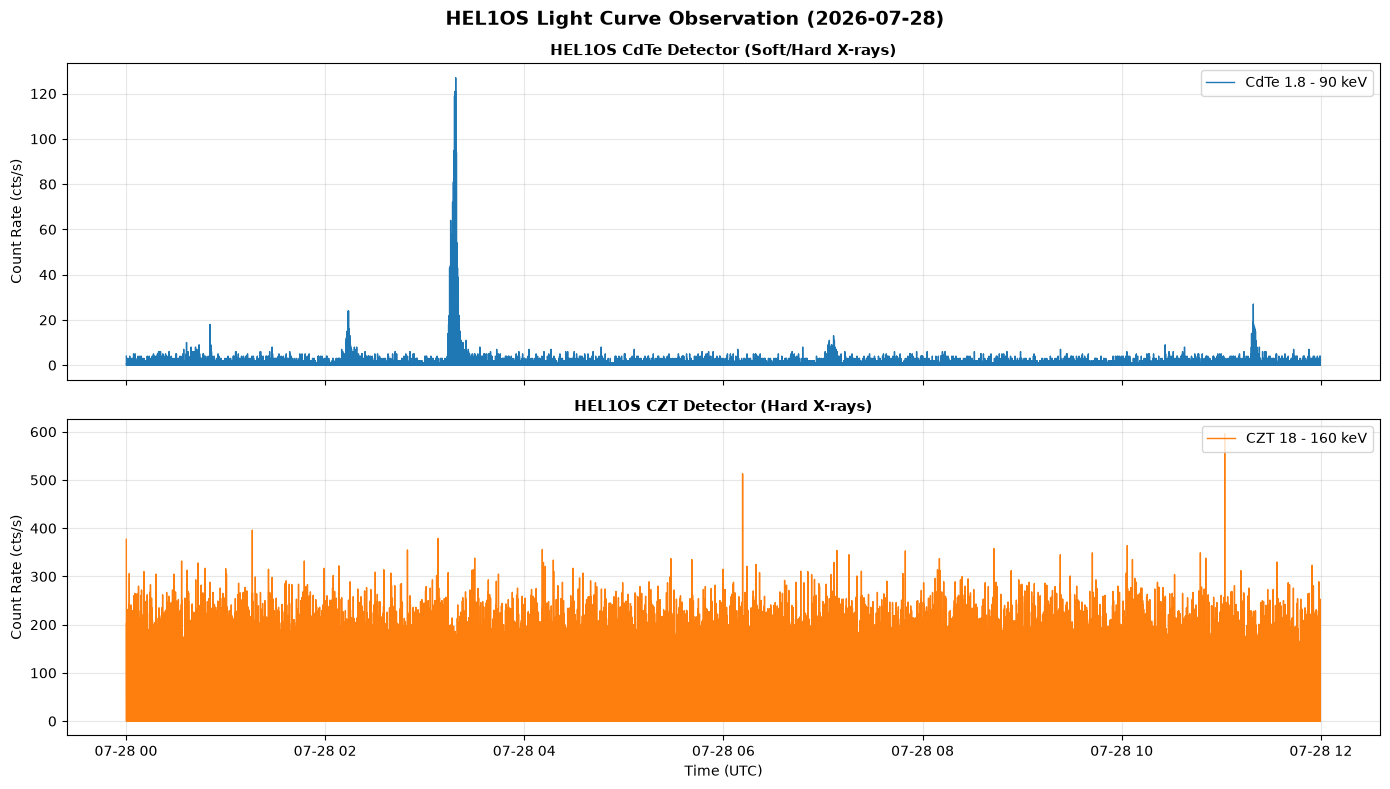

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f"HEL1OS Light Curve Observation ({df_cdte['time_dt'].dt.strftime('%Y-%m-%d').iloc[0]})", fontsize=14, fontweight="bold")

# Panel 1: CdTe Detector Count Rate
ax1 = axes[0]
ax1.plot(df_cdte["time_dt"], df_cdte["counts"], color="#1f77b4", linewidth=1, label="CdTe 1.8 - 90 keV")
ax1.set_title("HEL1OS CdTe Detector (Soft/Hard X-rays)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Count Rate (cts/s)")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Panel 2: CZT Detector Count Rate
ax2 = axes[1]
ax2.plot(df_czt["time_dt"], df_czt["counts"], color="#ff7f0e", linewidth=1, label="CZT 18 - 160 keV")
ax2.set_title("HEL1OS CZT Detector (Hard X-rays)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Time (UTC)")
ax2.set_ylabel("Count Rate (cts/s)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()